In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender  

In [4]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check whether conversion created missing values
print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

# Remove rows with missing TotalCharges, if any
df = df.dropna(subset=["TotalCharges"]).copy()

# Remove customer ID because it is only an identifier
df = df.drop(columns=["customerID"])

print("Shape after cleaning:", df.shape)
print("\nData types after cleaning:")
print(df.dtypes)

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Missing TotalCharges after conversion: 11
Shape after cleaning: (7032, 20)

Data types after cleaning:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Numerical summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


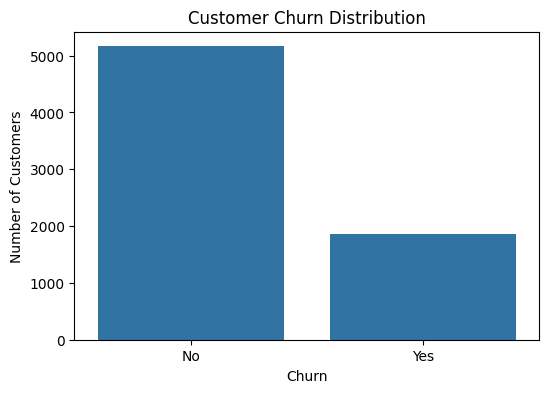

Churn percentage by contract type:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


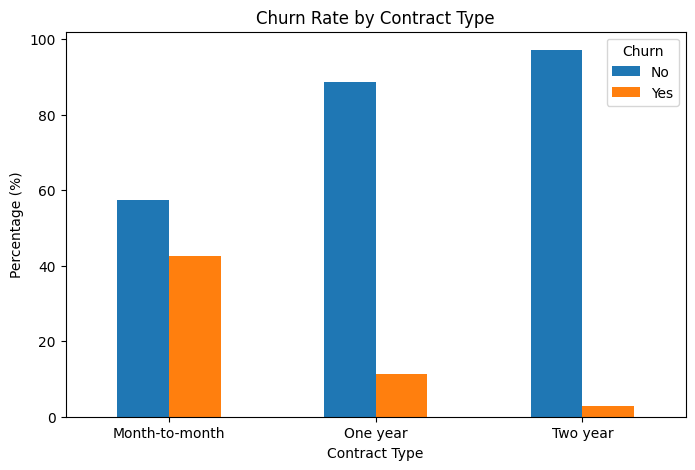

In [5]:
# Basic numerical summary
print("Numerical summary:")
display(df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe())

# Churn counts
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Churn rate by contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract type:")
display(contract_churn)

contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

Churn percentage by Internet Service:


Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


<Figure size 800x500 with 0 Axes>

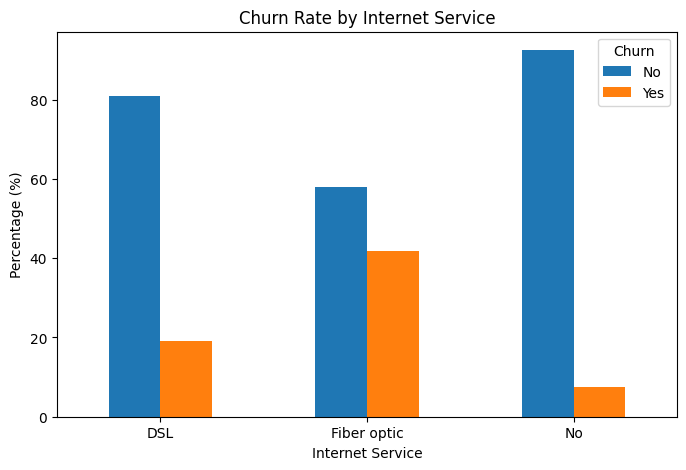

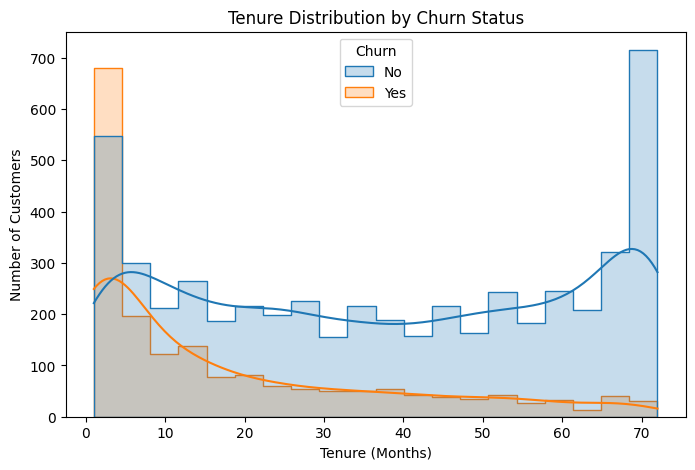

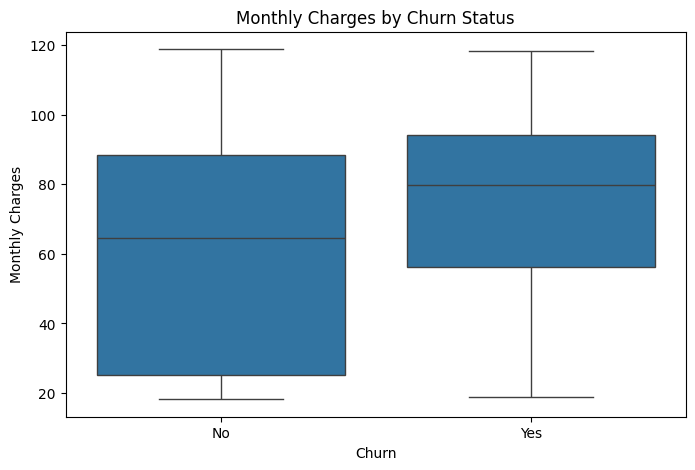

In [6]:
# Churn rate by Internet Service
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by Internet Service:")
display(internet_churn)

plt.figure(figsize=(8, 5))
internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


# Tenure distribution by churn
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=20,
    kde=True,
    element="step"
)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()


# Monthly charges by churn
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Churn percentage by Payment Method:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


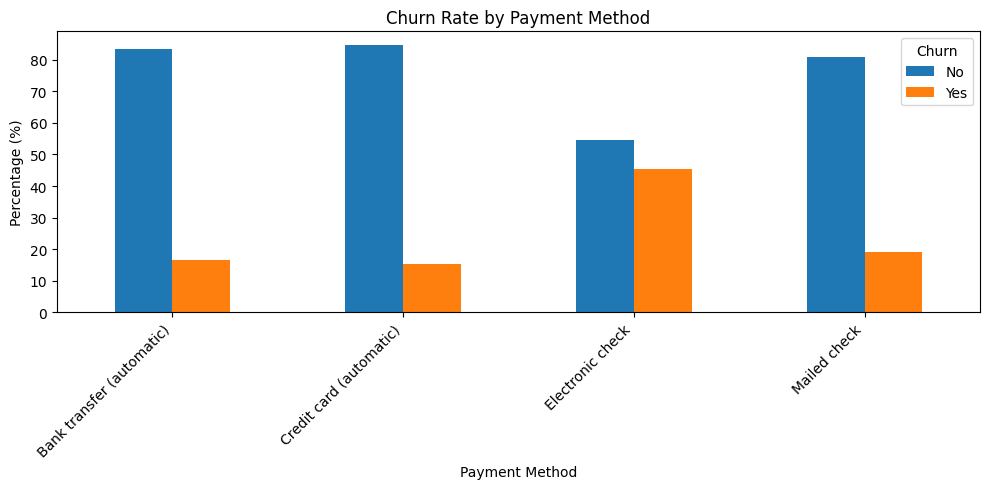

Churn percentage by Paperless Billing:


Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


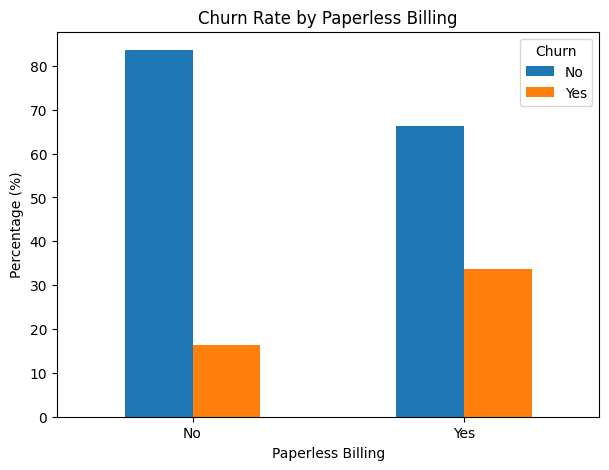

Churn percentage by Tech Support:


Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


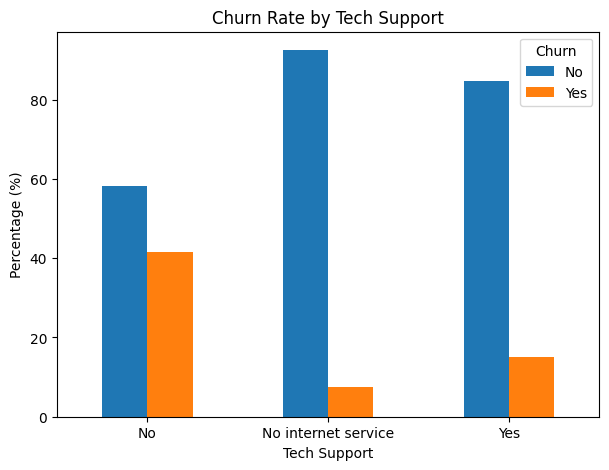

In [7]:
# Churn rate by payment method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by Payment Method:")
display(payment_churn)

payment_churn.plot(kind="bar", figsize=(10, 5))
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


# Churn rate by paperless billing
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by Paperless Billing:")
display(paperless_churn)

paperless_churn.plot(kind="bar", figsize=(7, 5))
plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


# Churn rate by tech support
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by Tech Support:")
display(support_churn)

support_churn.plot(kind="bar", figsize=(7, 5))
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [8]:
# Convert target variable to binary
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# One-hot encode categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("\nEncoded feature shape:", X_encoded.shape)
print("\nFirst 5 rows of encoded data:")
display(X_encoded.head())

Feature shape: (7032, 19)
Target shape: (7032,)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Encoded feature shape: (7032, 30)

First 5 rows of encoded data:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining churn percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting churn percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training feature shape: (5625, 30)
Testing feature shape: (1407, 30)

Training target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64

Training churn percentage:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Testing churn percentage:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [10]:
# Scale numerical features
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only the original numerical columns
X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Scaling completed.")
print("\nTraining data sample:")
display(X_train_scaled.head())

Scaling completed.

Training data sample:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,-0.439319,1.321816,0.981556,1.659900,1,1,1,1,0,1,...,0,0,0,0,0,1,0,1,0,0
7003,-0.439319,-0.267410,-0.971546,-0.562252,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3355,-0.439319,1.444064,0.837066,1.756104,0,1,0,1,0,1,...,0,0,0,0,0,1,0,1,0,0
4494,-0.439319,-1.204646,0.641092,-0.908326,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
3541,-0.439319,0.669826,-0.808787,-0.101561,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0


In [11]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Probability of churn
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully.")
print("First 20 predictions:")
print(y_pred_logistic[:20])

print("\nFirst 20 actual values:")
print(y_test.values[:20])

Logistic Regression model trained successfully.
First 20 predictions:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]

First 20 actual values:
[0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0]


Logistic Regression Performance
--------------------------------
Accuracy : 0.8053
Precision: 0.6515
Recall   : 0.5749
F1 Score : 0.6108
ROC-AUC  : 0.8361

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



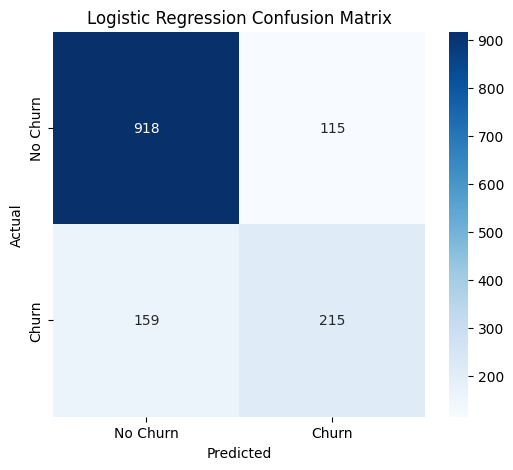

In [12]:
# Logistic Regression evaluation

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Churn", "Churn"]
))

# Confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Probability of churn
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")
print("First 20 predictions:")
print(y_pred_rf[:20])

Random Forest model trained successfully.
First 20 predictions:
[0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


Random Forest Performance
-------------------------
Accuracy : 0.7640
Precision: 0.5404
Recall   : 0.7513
F1 Score : 0.6286
ROC-AUC  : 0.8360

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1033
       Churn       0.54      0.75      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407



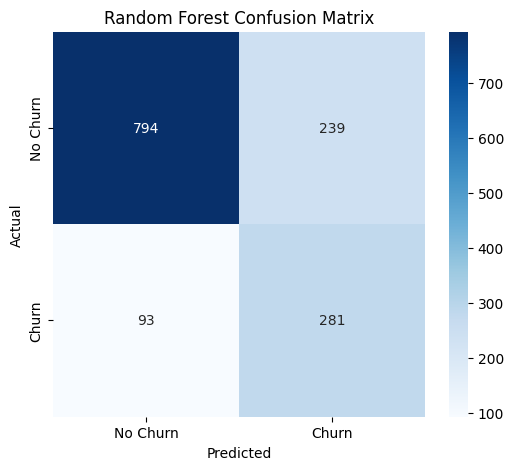

In [14]:
# Random Forest evaluation

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108,0.8361
1,Random Forest,0.7640,0.5404,0.7513,0.6286,0.8360


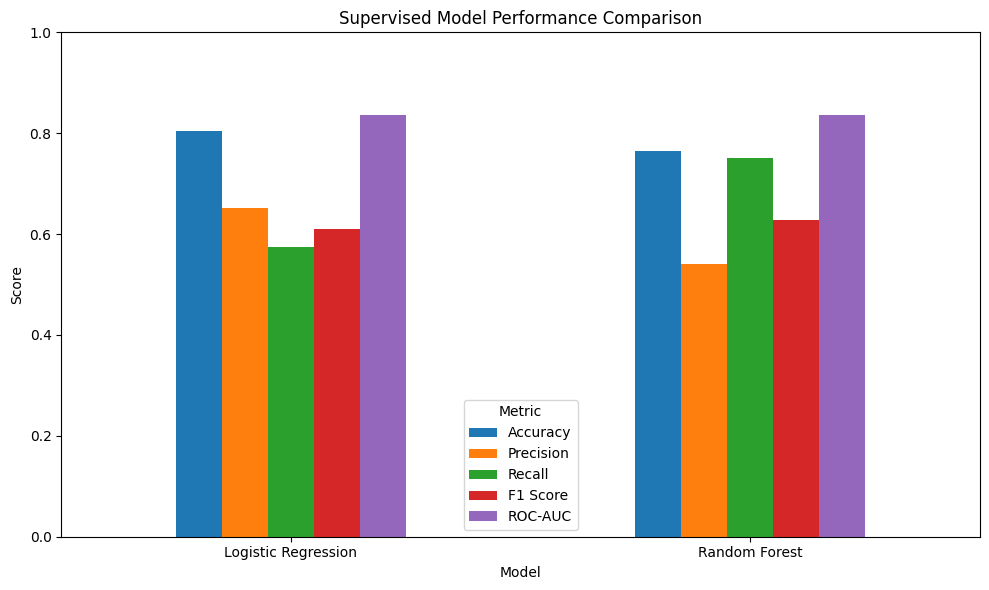

In [15]:
# Compare both models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_logistic, accuracy_rf],
    "Precision": [precision_logistic, precision_rf],
    "Recall": [recall_logistic, recall_rf],
    "F1 Score": [f1_logistic, f1_rf],
    "ROC-AUC": [roc_auc_logistic, roc_auc_rf]
})

print("Model Performance Comparison:")
display(comparison.round(4))


# Visualization
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Supervised Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

Top 15 features:


,Feature,Importance
1,tenure,0.179136
3,TotalCharges,0.143791
25,Contract_Two year,0.106422
2,MonthlyCharges,0.103523
10,InternetService_Fiber optic,0.064801
28,PaymentMethod_Electronic check,0.049403
24,Contract_One year,0.042982
13,OnlineSecurity_Yes,0.033430
19,TechSupport_Yes,0.023038
26,PaperlessBilling_Yes,0.017775


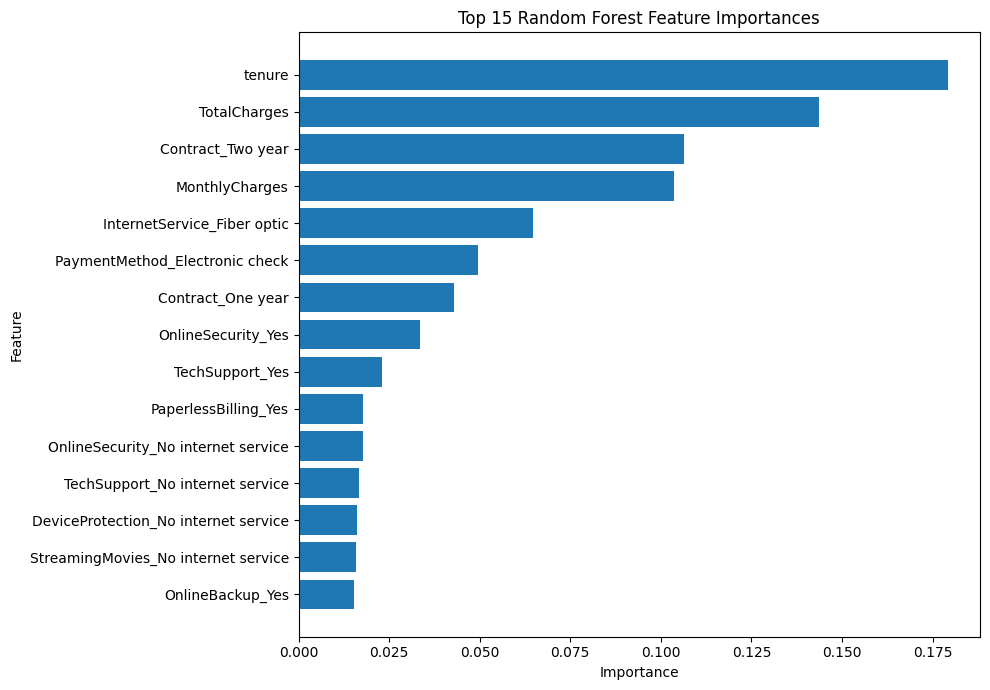

In [16]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 features:")
display(feature_importance.head(15))


# Plot top 15 features
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create a simple service-count feature
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_cluster = df.copy()

# Count services that are actively subscribed to
df_cluster["NumServices"] = 0

for col in service_columns:
    df_cluster["NumServices"] += (
        df_cluster[col].isin(["Yes"])
    ).astype(int)

# Select clustering features
cluster_features = [
    "tenure",
    "MonthlyCharges",
    "NumServices"
]

X_cluster = df_cluster[cluster_features].copy()

print("Clustering features:")
display(X_cluster.head())

print("\nClustering feature summary:")
display(X_cluster.describe())

Clustering features:


,tenure,MonthlyCharges,NumServices
0,1,29.85,1
1,34,56.95,3
2,2,53.85,3
3,45,42.30,3
4,2,70.70,1



Clustering feature summary:


,tenure,MonthlyCharges,NumServices
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,3.363339
std,24.545260,30.085974,2.062067
min,1.000000,18.250000,0.000000
25%,9.000000,35.587500,1.000000
50%,29.000000,70.350000,3.000000
75%,55.000000,89.862500,5.000000
max,72.000000,118.750000,8.000000


Silhouette scores:


,Number of Clusters,Silhouette Score
0,2,0.4256
1,3,0.4056
2,4,0.4211
3,5,0.3834
4,6,0.3948
5,7,0.3799
6,8,0.3658


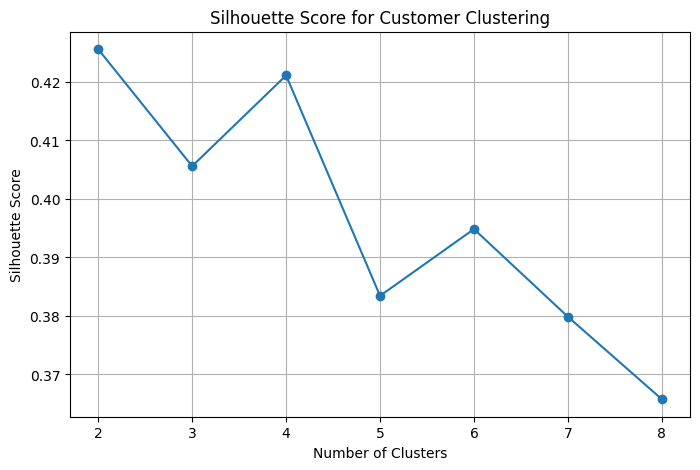

In [18]:
# Standardize clustering features
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Test different numbers of clusters
silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": range(2, 9),
    "Silhouette Score": silhouette_scores
})

print("Silhouette scores:")
display(silhouette_results.round(4))

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results["Number of Clusters"],
    silhouette_results["Silhouette Score"],
    marker="o"
)
plt.title("Silhouette Score for Customer Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

In [19]:
# Final K-Means model with 2 clusters

final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to the clustering dataframe
df_cluster["Cluster"] = cluster_labels

print("Cluster counts:")
print(df_cluster["Cluster"].value_counts().sort_index())

print("\nCluster profile:")
cluster_profile = df_cluster.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "NumServices"]
].mean()

display(cluster_profile.round(2))

Cluster counts:
Cluster
0    3147
1    3885
Name: count, dtype: int64

Cluster profile:


,tenure,MonthlyCharges,NumServices
Cluster,,,
0,46.61,89.47,5.28
1,20.93,44.82,1.81


In [20]:
# Calculate churn rate within each cluster

cluster_churn = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Churn"],
    normalize="index"
) * 100

print("Churn percentage by customer cluster:")
display(cluster_churn.round(2))

Churn percentage by customer cluster:


Churn,0,1
Cluster,,
0,75.79,24.21
1,71.51,28.49


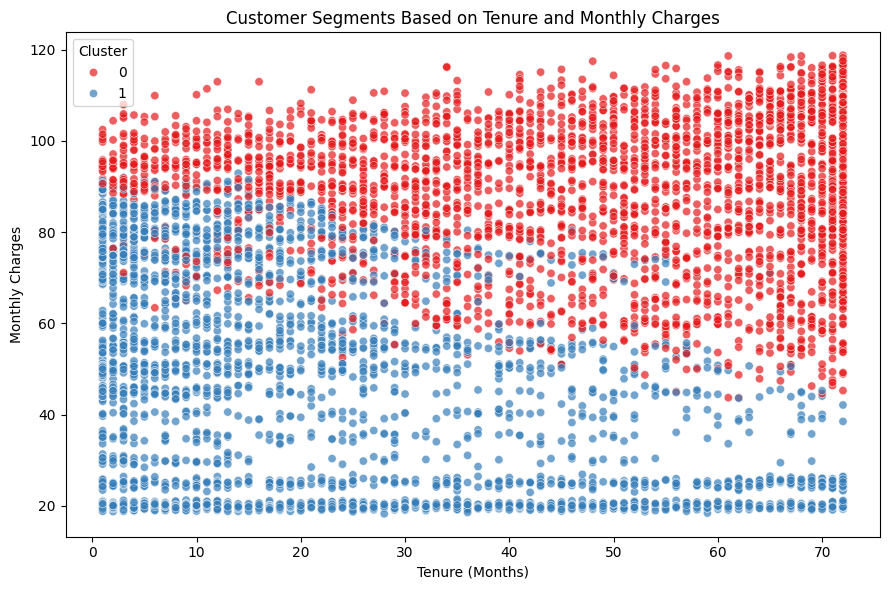

In [21]:
# Visualize customer clusters

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cluster,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("Customer Segments Based on Tenure and Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression cross-validation
logistic_cv = cross_validate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

# Random Forest cross-validation
rf_cv = cross_validate(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        class_weight="balanced"
    ),
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression Mean": [
        logistic_cv["test_accuracy"].mean(),
        logistic_cv["test_precision"].mean(),
        logistic_cv["test_recall"].mean(),
        logistic_cv["test_f1"].mean(),
        logistic_cv["test_roc_auc"].mean()
    ],
    "Random Forest Mean": [
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean(),
        rf_cv["test_roc_auc"].mean()
    ]
})

print("5-Fold Cross-Validation Results:")
display(cv_results.round(4))

5-Fold Cross-Validation Results:


,Metric,Logistic Regression Mean,Random Forest Mean
0,Accuracy,0.8028,0.7776
1,Precision,0.6558,0.5636
2,Recall,0.5452,0.7244
3,F1 Score,0.5952,0.6339
4,ROC-AUC,0.8461,0.8463


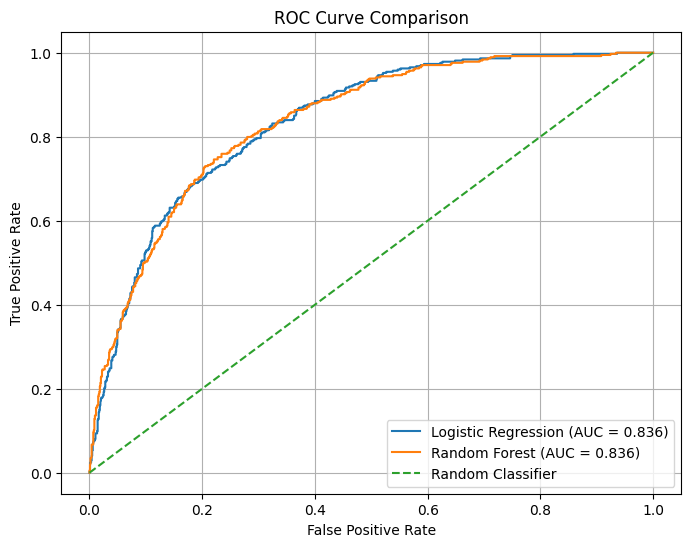

In [23]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Add cluster labels back to the cleaned customer dataset
final_df = df.copy()

final_df["Cluster"] = df_cluster["Cluster"].values

# Save processed dataset
final_df.to_csv(
    "telco_customer_churn_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")
print("Shape:", final_df.shape)
display(final_df.head())

Processed dataset saved successfully.
Shape: (7032, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1


In [25]:
import os

print("File verification:")
print(
    "telco_customer_churn_processed.csv:",
    os.path.exists("telco_customer_churn_processed.csv")
)
print(
    "logistic_regression_churn_model.pkl:",
    os.path.exists("logistic_regression_churn_model.pkl")
)
print(
    "random_forest_churn_model.pkl:",
    os.path.exists("random_forest_churn_model.pkl")
)

File verification:
telco_customer_churn_processed.csv: True
logistic_regression_churn_model.pkl: False
random_forest_churn_model.pkl: False


In [26]:
# Final results summary

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_logistic, accuracy_rf],
    "Precision": [precision_logistic, precision_rf],
    "Recall": [recall_logistic, recall_rf],
    "F1 Score": [f1_logistic, f1_rf],
    "ROC-AUC": [roc_auc_logistic, roc_auc_rf]
})

display(final_results.round(4))

print("\nBest model by churn recall:")
print(
    final_results.loc[
        final_results["Recall"].idxmax(),
        ["Model", "Recall"]
    ]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108,0.8361
1,Random Forest,0.7640,0.5404,0.7513,0.6286,0.8360



Best model by churn recall:
Model     Random Forest
Recall         0.751337
Name: 1, dtype: object


In [27]:
import joblib

# Save Logistic Regression model
joblib.dump(
    logistic_model,
    "logistic_regression_churn_model.pkl"
)

# Save Random Forest model
joblib.dump(
    rf_model,
    "random_forest_churn_model.pkl"
)

print("Both models saved successfully.")

Both models saved successfully.


In [28]:
import os

print("Logistic Regression model:",
      os.path.exists("logistic_regression_churn_model.pkl"))

print("Random Forest model:",
      os.path.exists("random_forest_churn_model.pkl"))

Logistic Regression model: True
Random Forest model: True
